#  Supervised Node Classification model using GATv2 with temporal decay weights to detect Credit card and payment fraud transactions

In [ ]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
os.environ['TORCH']=torch.__version__
print(torch.__version__)

!pip install -q pyg_lib -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install -q git+https://github.com/pyg-team/pytorch_geometric.git


from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report, precision_recall_curve
from torch_geometric.utils import to_undirected
from torch_geometric.data import Data

import torch_geometric.utils
import networkx as nx
import torch.nn.functional as F
import torch.optim as optim

from torch.nn import Linear
from torch_geometric.nn import GATv2Conv

2.9.0+cu126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.9/28.9 MB 59.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 77.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 31.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from google.colab import userdata
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')
print("Kaggle credentials configured.")

Kaggle credentials configured.


*Dataset : sergionefedov/fraud-detection-1m-transactions-7-fraud-types*

In [ ]:
 !kaggle datasets download -d sergionefedov/fraud-detection-1m-transactions-7-fraud-types
 !unzip fraud-detection-1m-transactions-7-fraud-types.zip

Dataset URL: https://www.kaggle.com/datasets/sergionefedov/fraud-detection-1m-transactions-7-fraud-types
License(s): apache-2.0
  0% 0.00/40.5M [00:00<?, ?B/s]
100% 40.5M/40.5M [00:00<00:00, 1.66GB/s]
Archive:  fraud-detection-1m-transactions-7-fraud-types.zip
  inflating: account_profiles.csv    
  inflating: fraud_column_descriptions.txt  
  inflating: fraud_patterns.csv      
  inflating: network_edges.csv       
  inflating: time_series_stats.csv   
  inflating: transactions.csv        


In [ ]:
!ls *.csv

account_profiles.csv  network_edges.csv      transactions.csv
fraud_patterns.csv    time_series_stats.csv


In [ ]:
df = pd.read_csv('transactions.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   transaction_id       1000000 non-null  object 
 1   account_id           1000000 non-null  object 
 2   timestamp            1000000 non-null  object 
 3   hour_of_day          1000000 non-null  int64  
 4   day_of_week          1000000 non-null  int64  
 5   is_weekend           1000000 non-null  int64  
 6   amount               1000000 non-null  float64
 7   merchant_category    1000000 non-null  object 
 8   mcc_code             1000000 non-null  int64  
 9   merchant_country     1000000 non-null  object 
 10  card_present         1000000 non-null  int64  
 11  device_type          1000000 non-null  object 
 12  device_known         1000000 non-null  int64  
 13  ip_risk_score        1000000 non-null  float64
 14  is_foreign_txn       1000000 non-null  int64  
 15 

In [ ]:
display(df.describe())

,hour_of_day,day_of_week,is_weekend,amount,mcc_code,card_present,device_known,ip_risk_score,is_foreign_txn,time_since_last_s,velocity_1h,amount_vs_avg_ratio,account_age_days,has_2fa,credit_limit,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.494197,3.003311,0.287152,183.738264,5703.713286,0.350654,0.892337,21.605828,0.294417,180.112610,1.050421,3.298512,1833.588908,0.647567,6706.938185,0.017143
std,6.920962,2.002666,0.452433,316.693903,548.917957,0.477175,0.309954,16.269652,0.455780,180.148636,1.095055,7.157055,1046.489932,0.477728,6174.164106,0.129804
min,0.000000,0.000000,0.000000,1.830000,4511.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.011800,30.000000,0.000000,500.000000,0.000000
25%,5.000000,1.000000,0.000000,43.480000,5411.000000,0.000000,1.000000,8.500000,0.000000,52.000000,0.000000,0.597100,926.000000,0.000000,2833.750000,0.000000
50%,11.000000,3.000000,0.000000,81.140000,5734.000000,0.000000,1.000000,18.700000,0.000000,125.000000,1.000000,1.285300,1832.000000,1.000000,4880.100000,0.000000
75%,17.000000,5.000000,1.000000,189.760000,5999.000000,1.000000,1.000000,30.700000,1.000000,250.000000,2.000000,3.155500,2738.000000,1.000000,8384.040000,0.000000
max,23.000000,6.000000,1.000000,25000.000000,7995.000000,1.000000,1.000000,100.000000,1.000000,2733.000000,15.000000,945.537100,3649.000000,1.000000,50000.000000,1.000000


In [ ]:
df = df.drop(columns=['fraud_pattern','mcc_code','day_of_week','hour_of_day','transaction_id'])

In [ ]:
df = pd.get_dummies(df, columns=['device_type'], prefix='device', dtype=int)

df = pd.get_dummies(df, columns=['merchant_category'], prefix='m_category', dtype='int8')

df = pd.get_dummies(df, columns=['merchant_country'], prefix='country', dtype='int8')

In [ ]:
device_cols = [col for col in df.columns if 'device_' in col]
display(df[device_cols].head())
print(df[device_cols].info())

,device_known,device_atm,device_mobile_app,device_phone_ivr,device_pos_terminal,device_web_browser
0,1,0,1,0,0,0
1,1,0,0,0,0,1
2,1,0,0,0,0,1
3,1,0,1,0,0,0
4,1,0,0,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   device_known         1000000 non-null  int64
 1   device_atm           1000000 non-null  int64
 2   device_mobile_app    1000000 non-null  int64
 3   device_phone_ivr     1000000 non-null  int64
 4   device_pos_terminal  1000000 non-null  int64
 5   device_web_browser   1000000 non-null  int64
dtypes: int64(6)
memory usage: 45.8 MB
None


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year'] = df['timestamp'].dt.year

#Sort the dataset chronologically
df = df.sort_values('timestamp').reset_index(drop=True)

In [ ]:
df_train = df[df['year'] == 2022].copy()
df_val = df[df['year'] == 2023].copy()
df_test = df[df['year'] == 2024].copy()

In [ ]:
zero_point = df_train['timestamp'].min()

df_train['time_elapsed_hours'] = (df_train['timestamp'] - zero_point).dt.total_seconds()/ 3600.0
df_val['time_elapsed_hours'] = (df_val['timestamp'] - zero_point).dt.total_seconds() / 3600.0
df_test['time_elapsed_hours'] = (df_test['timestamp'] - zero_point).dt.total_seconds() / 3600.0

print(f"Zero Point established at: {zero_point}\n")

display(df_train[['timestamp', 'time_elapsed_hours']].head())

display(df_test[['timestamp', 'time_elapsed_hours']].tail())

Zero Point established at: 2022-01-01 00:00:01



,timestamp,time_elapsed_hours
0,2022-01-01 00:00:01,0.000000
1,2022-01-01 00:02:54,0.048056
2,2022-01-01 00:03:29,0.057778
3,2022-01-01 00:05:39,0.093889
4,2022-01-01 00:06:10,0.102500


,timestamp,time_elapsed_hours
999995,2024-12-30 23:50:35,26279.842778
999996,2024-12-30 23:54:39,26279.910556
999997,2024-12-30 23:57:24,26279.956389
999998,2024-12-30 23:57:25,26279.956667
999999,2024-12-30 23:59:34,26279.992500


In [ ]:
for dataset in [df_train, df_val, df_test]:

    # Micro-Seasonality
    hours_in_day = 24.0
    dataset['hour_sin'] = np.sin(2 * np.pi * dataset['timestamp'].dt.hour / hours_in_day)
    dataset['hour_cos'] = np.cos(2 * np.pi * dataset['timestamp'].dt.hour / hours_in_day)

    days_in_week = 7.0
    # pandas .dt.dayofweek returns 0 (Monday) to 6 (Sunday)
    dataset['day_sin'] = np.sin(2 * np.pi * dataset['timestamp'].dt.dayofweek / days_in_week)
    dataset['day_cos'] = np.cos(2 * np.pi * dataset['timestamp'].dt.dayofweek / days_in_week)

    # Macro-Seasonality
    months_in_year = 12.0
    dataset['month_sin'] = np.sin(2 * np.pi * dataset['timestamp'].dt.month / months_in_year)
    dataset['month_cos'] = np.cos(2 * np.pi * dataset['timestamp'].dt.month / months_in_year)

In [ ]:
y_train = torch.tensor(df_train['is_fraud'].values, dtype=torch.float32).unsqueeze(1)
y_val   = torch.tensor(df_val['is_fraud'].values, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(df_test['is_fraud'].values, dtype=torch.float32).unsqueeze(1)

#dropping the columns-'is_fraud','year'
df_train=df_train.drop(columns=['is_fraud','year'])
df_val=df_val.drop(columns=['is_fraud','year'])
df_test=df_test.drop(columns=['is_fraud','year'])

In [ ]:
print(f"Graph A (Train 2022): {len(df_train):,} nodes | Target Shape: {y_train.shape}")
print(f"Graph B (Val 2023):   {len(df_val):,} nodes | Target Shape: {y_val.shape}")
print(f"Graph C (Test 2024):  {len(df_test):,} nodes | Target Shape: {y_test.shape}")

Graph A (Train 2022): 333,723 nodes | Target Shape: torch.Size([333723, 1])
Graph B (Val 2023):   332,362 nodes | Target Shape: torch.Size([332362, 1])
Graph C (Test 2024):  333,915 nodes | Target Shape: torch.Size([333915, 1])


In [ ]:
print(f"\nAccount ID dtype in Train: {df_train['account_id'].dtype}")


Account ID dtype in Train: object


In [ ]:
scaler_time = RobustScaler()
scaler_amount = RobustScaler()
scaler_credit = RobustScaler()
scaler_age = RobustScaler()
scaler_velocity = RobustScaler()
scaler_dormancy = RobustScaler()
scaler_ratio = RobustScaler()

In [ ]:
for dataset in [df_train, df_val, df_test]:
    dataset['amount_log'] = np.log1p(dataset['amount'])
    dataset['credit_limit_log'] = np.log1p(dataset['credit_limit'])
    dataset['velocity_1h_log'] = np.log1p(dataset['velocity_1h'])
    dataset['time_since_last_s_log'] = np.log1p(dataset['time_since_last_s'])
    dataset['ratio_log'] = np.log1p(dataset['amount_vs_avg_ratio'])

In [ ]:
scaler_time.fit(df_train[['time_elapsed_hours']])
scaler_amount.fit(df_train[['amount_log']])
scaler_credit.fit(df_train[['credit_limit_log']])
scaler_age.fit(df_train[['account_age_days']])
scaler_velocity.fit(df_train[['velocity_1h_log']])
scaler_dormancy.fit(df_train[['time_since_last_s_log']])
scaler_ratio.fit(df_train[['ratio_log']])

RobustScaler()

In [ ]:
df_train['time_elapsed_hours'] = scaler_time.transform(df_train[['time_elapsed_hours']])
df_val['time_elapsed_hours'] = scaler_time.transform(df_val[['time_elapsed_hours']])
df_test['time_elapsed_hours'] = scaler_time.transform(df_test[['time_elapsed_hours']])

for dataset in [df_train, df_val, df_test]:
    dataset['amount'] = scaler_amount.transform(dataset[['amount_log']])
    dataset['credit_limit'] = scaler_credit.transform(dataset[['credit_limit_log']])
    dataset['account_age_days'] = scaler_age.transform(dataset[['account_age_days']])
    dataset['velocity_1h'] = scaler_velocity.transform(dataset[['velocity_1h_log']])
    dataset['time_since_last_s'] = scaler_dormancy.transform(dataset[['time_since_last_s_log']])
    dataset['amount_vs_avg_ratio'] = scaler_ratio.transform(dataset[['ratio_log']])


# Drop the temporary log columns
for dataset in [df_train, df_val, df_test]:
    dataset.drop(columns=['amount_log', 'credit_limit_log'], inplace=True, errors='ignore')
    dataset.drop(columns=['velocity_1h_log', 'time_since_last_s_log'], inplace=True, errors='ignore')
    dataset.drop(columns=['ratio_log'], inplace=True, errors='ignore')

In [ ]:
print(f"2022 (Train) Median Scaled Time: {df_train['time_elapsed_hours'].median():.2f}")
print(f"2023 (Val)   Median Scaled Time: {df_val['time_elapsed_hours'].median():.2f}")
print(f"2024 (Test)  Median Scaled Time: {df_test['time_elapsed_hours'].median():.2f}")
print(f"Amount Median:       {df_train['amount'].median():.4f}")
print(f"Amount Max (Scaled): {df_train['amount'].max():.4f}")
print(f"Credit Limit Median: {df_train['credit_limit'].median():.4f}")
print(f"Account Age Median: {df_train['account_age_days'].median():.4f}")
print(f"Velocity 1H Max:    {df_train['velocity_1h'].max():.4f}")
print(f"Time Since Last Max:{df_train['time_since_last_s'].max():.4f}")
print(f"Amount vs Avg Ratio Max: {df_train['amount_vs_avg_ratio'].max():.4f}")

2022 (Train) Median Scaled Time: 0.00
2023 (Val)   Median Scaled Time: 2.00
2024 (Test)  Median Scaled Time: 4.01
Amount Median:       0.0000
Amount Max (Scaled): 3.8536
Credit Limit Median: 0.0000
Account Age Median: 0.0000
Velocity 1H Max:    1.8340
Time Since Last Max:1.9153
Amount vs Avg Ratio Max: 5.8108


In [ ]:
for dataset in [df_train, df_val, df_test]:
    dataset['ip_risk_score'] = dataset['ip_risk_score'] / 100.0

print(f"IP Risk Score Max:{df_train['ip_risk_score'].max():.4f}")

IP Risk Score Max:1.0000


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333723 entries, 0 to 333722
Data columns (total 51 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   account_id                 333723 non-null  object        
 1   timestamp                  333723 non-null  datetime64[ns]
 2   is_weekend                 333723 non-null  int64         
 3   amount                     333723 non-null  float64       
 4   card_present               333723 non-null  int64         
 5   device_known               333723 non-null  int64         
 6   ip_risk_score              333723 non-null  float64       
 7   is_foreign_txn             333723 non-null  int64         
 8   time_since_last_s          333723 non-null  float64       
 9   velocity_1h                333723 non-null  float64       
 10  amount_vs_avg_ratio        333723 non-null  float64       
 11  account_age_days           333723 non-null  float64      

In [ ]:
def transaction_graph(df, window=168, lambda_val=0.1):
    df = df.reset_index(drop=True)
    df['node_id'] = df.index

    df_edges = df[['node_id', 'account_id', 'timestamp']].merge(
        df[['node_id', 'account_id', 'timestamp']],
        on='account_id',
        suffixes=('_src', '_dst')
    )

    df_edges['time_diff'] = (df_edges['timestamp_dst'] - df_edges['timestamp_src']).dt.total_seconds() / 3600.0
    mask = (df_edges['time_diff'].abs() <= window) & (df_edges['node_id_src'] != df_edges['node_id_dst'])
    valid_edges = df_edges[mask].copy()

    time_diff = valid_edges['time_diff'].abs().values

 # Linear  Decay Weights
    w_linear = np.maximum(0, 1.0 - (time_diff / window))

 # Exponential Decay Weights
    w_exp = np.exp(-lambda_val * time_diff)

 # Piecewise Decay Weights
    w_step = np.piecewise(
        time_diff,
        [time_diff <= 24, (time_diff > 24) & (time_diff <= 72), (time_diff > 72) & (time_diff <= 120), time_diff > 120 ],
        [1.0, 0.75, 0.5, 0.25]
    )

    source_nodes = valid_edges['node_id_src'].values
    target_nodes = valid_edges['node_id_dst'].values
    edge_index = torch.tensor(np.vstack((source_nodes, target_nodes)), dtype=torch.long)

 # unsqueeze(1) : [num_edges] -> [num_edges, 1]
    edge_attr_linear = torch.tensor(w_linear, dtype=torch.float32).unsqueeze(1)
    edge_attr_exp    = torch.tensor(w_exp, dtype=torch.float32).unsqueeze(1)
    edge_attr_step   = torch.tensor(w_step, dtype=torch.float32).unsqueeze(1)

    print(f"Final Nodes: {len(df):,}")
    print(f"Final Undirected Edges: {edge_index.shape[1]:,}")
    return df, edge_index, edge_attr_linear, edge_attr_exp, edge_attr_step

In [ ]:
print("TRAINING GRAPH ")
(df_train, edge_index_train,
 attr_lin_train, attr_exp_train, attr_step_train) = transaction_graph(df_train, window=168)

print("\n VALIDATION GRAPH ")
(df_val, edge_index_val,
 attr_lin_val, attr_exp_val, attr_step_val) = transaction_graph(df_val, window=168)

print("\n TEST GRAPH ")
(df_test, edge_index_test,
 attr_lin_test, attr_exp_test, attr_step_test) = transaction_graph(df_test, window=168)

TRAINING GRAPH 
Final Nodes: 333,723
Final Undirected Edges: 136,528

 VALIDATION GRAPH 
Final Nodes: 332,362
Final Undirected Edges: 135,420

 TEST GRAPH 
Final Nodes: 333,915
Final Undirected Edges: 136,956


In [ ]:
def create_pyg_data(df_features, y_tensor, edge_index, edge_attr):

    cols_to_drop = ['account_id', 'timestamp', 'year', 'node_id', 'is_fraud']
    df_clean = df_features.drop(columns=cols_to_drop, errors='ignore')

    x_tensor = torch.tensor(df_clean.values, dtype=torch.float32)

    data = Data(
        x=x_tensor,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=y_tensor
    )

    return data

In [ ]:
print("--- data ---")
data_train = create_pyg_data(df_train, y_train, edge_index_train, attr_exp_train)
print(f"2022 Train Graph: {data_train}")

data_val = create_pyg_data(df_val, y_val, edge_index_val, attr_exp_val)
print(f"2023 Val Graph:   {data_val}")

data_test = create_pyg_data(df_test, y_test, edge_index_test, attr_exp_test)
print(f"2024 Test Graph:  {data_test}")

--- data ---
2022 Train Graph: Data(x=[333723, 49], edge_index=[2, 136528], edge_attr=[136528, 1], y=[333723, 1])
2023 Val Graph:   Data(x=[332362, 49], edge_index=[2, 135420], edge_attr=[135420, 1], y=[332362, 1])
2024 Test Graph:  Data(x=[333915, 49], edge_index=[2, 136956], edge_attr=[136956, 1], y=[333915, 1])


In [ ]:
if torch.isnan(data_train.x).any():
    print("NaN values detected")
else:
    print("Feature matrix is clean")

Feature matrix is clean


In [ ]:
num_features = data_train.x.shape[1]
print(f"\nFinal Input Feature Dimension: {num_features}")


# Extract the column names that actually made it into the tensor
# cols_to_drop = ['account_id', 'timestamp', 'year', 'node_id', 'is_fraud']

feature_names = [col for col in df_train.columns]  #if col not in cols_to_drop
print(f"Total Input Features: {len(feature_names)}")
print("-" * 30)
for i, name in enumerate(feature_names):
    print(f"Index {i:02}: {name}")


Final Input Feature Dimension: 49
Total Input Features: 52
------------------------------
Index 00: account_id
Index 01: timestamp
Index 02: is_weekend
Index 03: amount
Index 04: card_present
Index 05: device_known
Index 06: ip_risk_score
Index 07: is_foreign_txn
Index 08: time_since_last_s
Index 09: velocity_1h
Index 10: amount_vs_avg_ratio
Index 11: account_age_days
Index 12: has_2fa
Index 13: credit_limit
Index 14: device_atm
Index 15: device_mobile_app
Index 16: device_phone_ivr
Index 17: device_pos_terminal
Index 18: device_web_browser
Index 19: m_category_atm
Index 20: m_category_clothing
Index 21: m_category_crypto
Index 22: m_category_electronics
Index 23: m_category_gambling
Index 24: m_category_gas_station
Index 25: m_category_grocery
Index 26: m_category_hotel
Index 27: m_category_money_transfer
Index 28: m_category_online_retail
Index 29: m_category_pharmacy
Index 30: m_category_restaurant
Index 31: m_category_travel
Index 32: m_category_utilities
Index 33: country_AU
Inde

In [ ]:
print("--- data_train Summary ---")
print(f"Node Feature Matrix (x):     {data_train.x.shape}  -> [Nodes, Features]")
print(f"Adjacency Matrix (edge_index): {data_train.edge_index.shape} -> [2, Edges]")
print(f"Edge Weights (edge_attr):    {data_train.edge_attr.shape}  -> [Edges, 1]")
print(f"Target Labels (y):           {data_train.y.shape}  -> [Nodes, 1]")

--- data_train Summary ---
Node Feature Matrix (x):     torch.Size([333723, 49])  -> [Nodes, Features]
Adjacency Matrix (edge_index): torch.Size([2, 136528]) -> [2, Edges]
Edge Weights (edge_attr):    torch.Size([136528, 1])  -> [Edges, 1]
Target Labels (y):           torch.Size([333723, 1])  -> [Nodes, 1]


In [ ]:
print("\nFirst Node Feature Vector (Scaled):")
print(data_train.x[0])


First Node Feature Vector (Scaled):
tensor([ 1.0000, -0.1412,  0.0000,  1.0000,  0.2140,  0.0000,  0.4015,  0.0000,
        -0.4203, -0.0320,  1.0000, -0.2177,  0.0000,  1.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  1.0000, -1.0030,  0.0000,  1.0000, -0.9749, -0.2225,  0.5000,
         0.8660])


In [ ]:
def Visualize(h,color):
  z= TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())
  plt.figure(figsize=(10,10))
  plt.xticks([])
  plt.yticks([])
  plt.scatter(z[:,0],z[:,1],s=70,c=color,cmap="Set2")
  plt.show()

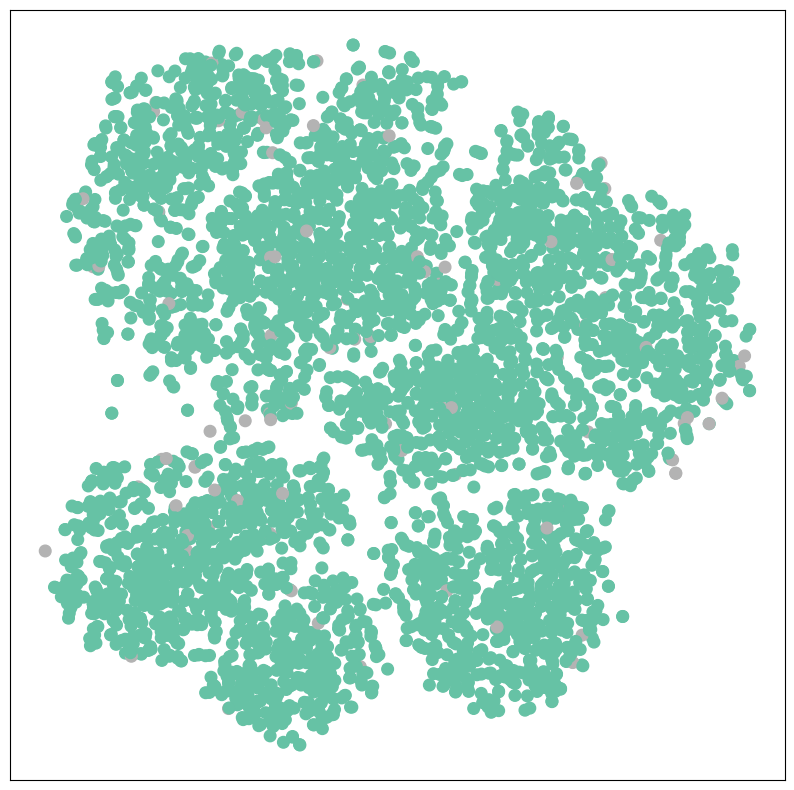

In [ ]:
h_sample = data_train.x[:5000]
color_sample = data_train.y[:5000].flatten().cpu().numpy()
Visualize(h_sample, color_sample)

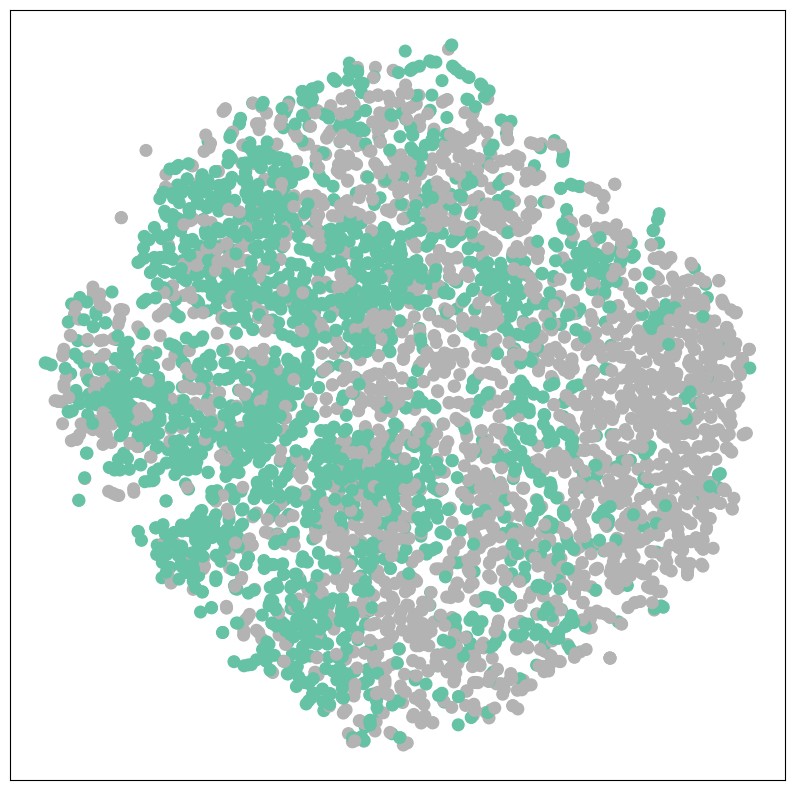

In [ ]:
fraud_indices = (data_train.y == 1).nonzero(as_tuple=True)[0].cpu().numpy()
normal_indices = (data_train.y == 0).nonzero(as_tuple=True)[0].cpu().numpy()

n_fraud = min(len(fraud_indices), 2500)
sample_fraud = np.random.choice(fraud_indices, n_fraud, replace=False)

sample_normal = np.random.choice(normal_indices, n_fraud, replace=False)

final_sample_indices = np.concatenate([sample_fraud, sample_normal])
np.random.shuffle(final_sample_indices)


h_viz = data_train.x[final_sample_indices]
color_viz = data_train.y[final_sample_indices].flatten().cpu().numpy()
Visualize(h_viz, color_viz)

In [ ]:
class GATv2(torch.nn.Module):
    def __init__(self, num_node_features, hidden_layer=16, num_heads=4):
        super(GATv2, self).__init__()

        self.conv1 = GATv2Conv(num_node_features, hidden_layer,
                               heads=num_heads, edge_dim=1)

        self.conv2 = GATv2Conv(hidden_layer* num_heads, hidden_layer,
                               heads=1, concat=False, edge_dim=1)

        self.out = Linear(hidden_layer, 1)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.elu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        # Slightly higher dropout for better generalization

        x = self.conv2(x, edge_index, edge_attr)
        x = F.elu(x)

        # Final Logit
        return self.out(x)


model = GATv2(
    num_node_features=data_train.x.shape[1],
    hidden_layer=16,
    num_heads=4
)

print(f"Input Features: {data_train.x.shape[1]}")
print(f"Model Architecture:\n{model}")

Input Features: 49
Model Architecture:
GATv2(
  (conv1): GATv2Conv(49, 16, heads=4)
  (conv2): GATv2Conv(64, 16, heads=1)
  (out): Linear(in_features=16, out_features=1, bias=True)
)


In [ ]:
# Calculate the ratio: Total Normal / Total Fraud
num_fraud = (data_train.y == 1).sum().item()
num_normal = (data_train.y == 0).sum().item()

# penalizing using pos_weight_tensor
pos_weight_value = num_normal / num_fraud
pos_weight_tensor = torch.tensor([pos_weight_value], dtype=torch.float32)

print(f"Fraud Count: {num_fraud}")
print(f"Normal Count: {num_normal}")
print(f"Loss Weight Multiplier: {pos_weight_value:.2f}")

Fraud Count: 5761
Normal Count: 327962
Loss Weight Multiplier: 56.93


In [ ]:
# Move model to GPU if available
device = torch.device('cuda')
model = model.to(device)
data_train = data_train.to(device)
data_val = data_val.to(device)

#Loss function with our calculated class weight
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor.to(device))

# Adam Optimizer
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_f1):
        if self.best_score is None:
            self.best_score = val_f1
        elif val_f1 < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_f1
            self.counter = 0


stopper = EarlyStopping(patience=15)

In [ ]:
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        # Forward pass
        logits = model(data.x, data.edge_index, data.edge_attr)
        # Convert logits to probabilities and then to binary predictions (threshold 0.5)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        # Move to CPU for sklearn
        y_true = data.y.cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        metrics = {
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'auc': roc_auc_score(y_true, y_probs)
        }
    return metrics

In [ ]:
epochs = 200
best_val_f1 = 0

# Initialize Stopper
stopper = EarlyStopping(patience=20)

In [ ]:
import time

In [ ]:
print("Starting GATv2 Training Phase...\n")

for epoch in range(1, epochs + 1):
    start_time = time.time()

    # training phase
    model.train()
    optimizer.zero_grad()

    # forward pass
    out = model(data_train.x, data_train.edge_index, data_train.edge_attr)
    loss = criterion(out, data_train.y)

    # Backpropagation
    loss.backward()
    optimizer.step()

    # validation metrics
    train_metrics = evaluate(model, data_train)
    val_metrics = evaluate(model, data_val)

    # Check Early Stopping
    stopper(val_metrics['f1'])

    # Save Best Model
    if val_metrics['f1'] > best_val_f1:
        best_val_f1 = val_metrics['f1']
        torch.save(model.state_dict(), 'best_gat_model.pt')
        status = "NEW BEST"
    else:
        status = ""

    # Print Progress every 5 epochs
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | "
              f"Train F1: {train_metrics['f1']:.3f} | "
              f"Val F1: {val_metrics['f1']:.3f} | "
              f"Val AUC: {val_metrics['auc']:.3f} | {status}")

    if stopper.early_stop:
        print(f"\nTarget reached. Early stopping triggered at epoch {epoch}.")
        break

print(f"\nTraining Complete. Best Validation F1: {best_val_f1:.4f}")

Starting GATv2 Training Phase...

Epoch 001 | Loss: 1.5720 | Train F1: 0.017 | Val F1: 0.019 | Val AUC: 0.236 | NEW BEST
Epoch 005 | Loss: 1.4878 | Train F1: 0.021 | Val F1: 0.023 | Val AUC: 0.281 | NEW BEST
Epoch 010 | Loss: 1.4037 | Train F1: 0.031 | Val F1: 0.029 | Val AUC: 0.414 | NEW BEST
Epoch 015 | Loss: 1.3315 | Train F1: 0.048 | Val F1: 0.038 | Val AUC: 0.618 | NEW BEST
Epoch 020 | Loss: 1.2676 | Train F1: 0.069 | Val F1: 0.051 | Val AUC: 0.745 | NEW BEST
Epoch 025 | Loss: 1.2081 | Train F1: 0.088 | Val F1: 0.065 | Val AUC: 0.799 | NEW BEST
Epoch 030 | Loss: 1.1512 | Train F1: 0.102 | Val F1: 0.078 | Val AUC: 0.827 | NEW BEST
Epoch 035 | Loss: 1.0980 | Train F1: 0.111 | Val F1: 0.088 | Val AUC: 0.845 | NEW BEST
Epoch 040 | Loss: 1.0466 | Train F1: 0.117 | Val F1: 0.097 | Val AUC: 0.859 | NEW BEST
Epoch 045 | Loss: 0.9967 | Train F1: 0.123 | Val F1: 0.106 | Val AUC: 0.872 | NEW BEST
Epoch 050 | Loss: 0.9494 | Train F1: 0.130 | Val F1: 0.116 | Val AUC: 0.882 | NEW BEST
Epoch 055

In [ ]:
model.load_state_dict(torch.load('best_gat_model.pt'))
model.eval() # Set to evaluation mode (turns off Dropout)

GATv2(
  (conv1): GATv2Conv(49, 16, heads=4)
  (conv2): GATv2Conv(64, 16, heads=1)
  (out): Linear(in_features=16, out_features=1, bias=True)
)

In [ ]:
test_metrics = evaluate(model, data_test.to(device))

print("=== FINAL 2024 TEST RESULTS ===")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-Score:  {test_metrics['f1']:.4f}")
print(f"AUC-ROC:   {test_metrics['auc']:.4f}")

=== FINAL 2024 TEST RESULTS ===
Precision: 0.2791
Recall:    0.8683
F1-Score:  0.4224
AUC-ROC:   0.9754


In [ ]:
# 2. Get indices for a 50/50 Balanced Sample from 2024
fraud_idx = (data_test.y == 1).nonzero(as_tuple=True)[0].cpu().numpy()
normal_idx = (data_test.y == 0).nonzero(as_tuple=True)[0].cpu().numpy()

n_viz = min(len(fraud_idx), 2500)
viz_indices = np.concatenate([
    np.random.choice(fraud_idx, n_viz, replace=False),
    np.random.choice(normal_idx, n_viz, replace=False)
])

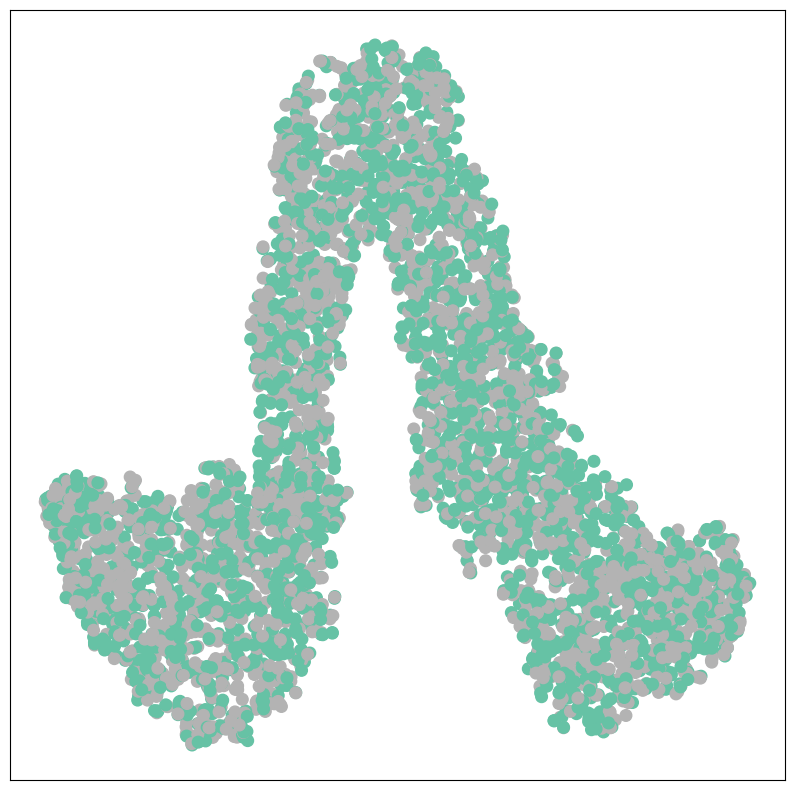

In [ ]:
# Optional: Visualize what the MODEL sees
model.eval()
with torch.no_grad():
    # We stop right after the second GATv2 layer (the bottleneck)
    h_hidden = model.conv2(
        F.elu(model.conv1(data_test.x, data_test.edge_index, data_test.edge_attr)),
        data_test.edge_index,
        data_test.edge_attr
    )
    h_hidden_sample = h_hidden[viz_indices]

Visualize(h_hidden_sample, color_viz)

Visualizing 10,000 nodes with REAL-WORLD imbalance (~151.0 fraud points)...


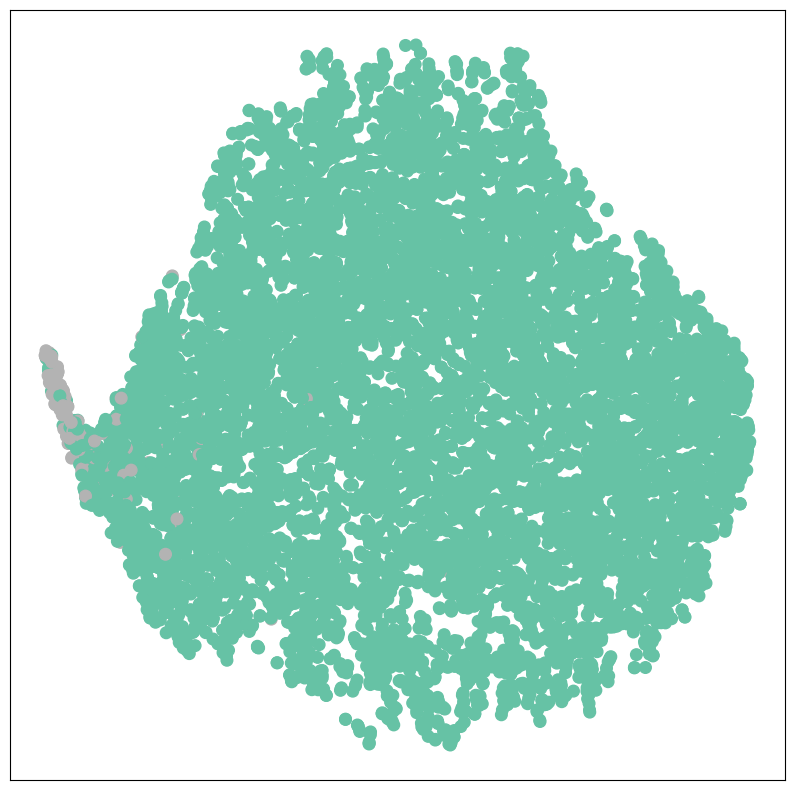

In [ ]:


# 1. Define the total sample size (10k is usually the limit for t-SNE speed)
total_sample_size = 10000

# 2. Randomly select 10,000 indices from the entire 2024 Test Set
# This naturally preserves the 57:1 imbalance
unbalanced_indices = np.random.choice(
    np.arange(len(data_test.y)),
    total_sample_size,
    replace=False
)

# 3. Extract the Raw Features (X) or the Model Embeddings (Hidden)
# Let's look at the Model Embeddings to see how the GATv2 organized the galaxy
model.eval()
with torch.no_grad():
    # Pass through Layer 1 -> ELU -> Layer 2
    h1 = F.elu(model.conv1(data_test.x, data_test.edge_index, data_test.edge_attr))
    h_hidden = model.conv2(h1, data_test.edge_index, data_test.edge_attr)

    h_viz_unbalanced = h_hidden[unbalanced_indices]
    color_viz_unbalanced = data_test.y[unbalanced_indices].flatten().cpu().numpy()

# 4. Execute the Visualize function
print(f"Visualizing 10,000 nodes with REAL-WORLD imbalance (~{color_viz_unbalanced.sum()} fraud points)...")
Visualize(h_viz_unbalanced, color_viz_unbalanced)

In [ ]:
import seaborn as sns

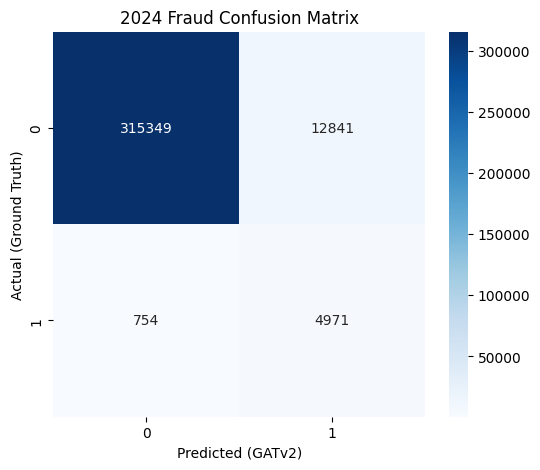

In [ ]:
with torch.no_grad():
    logits = model(data_test.x, data_test.edge_index, data_test.edge_attr)
    preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()
    y_true = data_test.y.cpu().numpy()

cm = confusion_matrix(y_true, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted (GATv2)')
plt.ylabel('Actual (Ground Truth)')
plt.title('2024 Fraud Confusion Matrix')
plt.show()

--- THRESHOLD OPTIMIZATION ---
Optimal Threshold: 0.9010
Max F1-Score:      0.6498
Precision at Best: 0.6673
Recall at Best:    0.6332


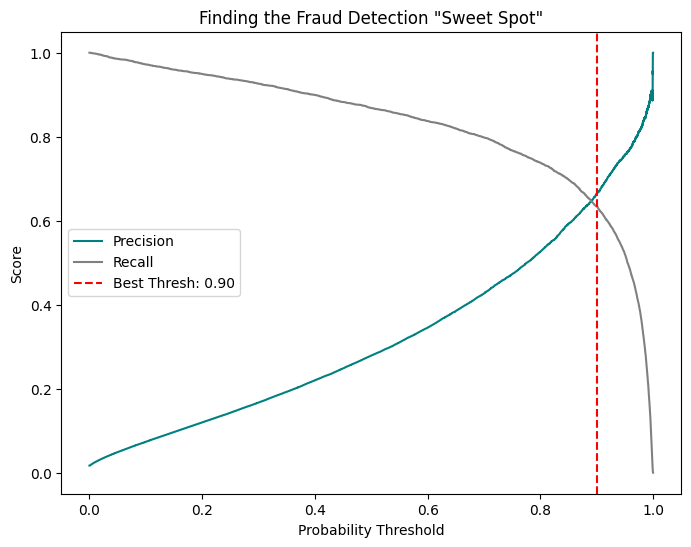

In [ ]:
# 1. Get raw probabilities
model.eval()
with torch.no_grad():
    logits = model(data_test.x, data_test.edge_index, data_test.edge_attr)
    probs = torch.sigmoid(logits).cpu().numpy()
    y_true = data_test.y.cpu().numpy()

# 2. Calculate Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_true, probs)

# 3. Calculate F1 for each threshold
# We add a tiny epsilon to avoid division by zero
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"--- THRESHOLD OPTIMIZATION ---")
print(f"Optimal Threshold: {best_thresh:.4f}")
print(f"Max F1-Score:      {f1_scores[best_idx]:.4f}")
print(f"Precision at Best: {precision[best_idx]:.4f}")
print(f"Recall at Best:    {recall[best_idx]:.4f}")

# 4. Visualize the Tradeoff
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color='teal')
plt.plot(thresholds, recall[:-1], label='Recall', color='gray')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Best Thresh: {best_thresh:.2f}')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Finding the Fraud Detection "Sweet Spot"')
plt.legend()
plt.show()

In [ ]:
# Create new Data objects using the LINEAR weights
data_train_lin = create_pyg_data(df_train, y_train, edge_index_train, attr_lin_train)
data_val_lin   = create_pyg_data(df_val, y_val, edge_index_val, attr_lin_val)
data_test_lin  = create_pyg_data(df_test, y_test, edge_index_test, attr_lin_test)

print(f"Linear Graph Ready: {data_train_lin.edge_attr.shape}")

Linear Graph Ready: torch.Size([136528, 1])


In [ ]:
# 1. Reset Model (New weights, fresh start)
model_lin = GATv2(num_node_features=data_train_lin.x.shape[1], hidden_layer=16).to(device)
optimizer_lin = torch.optim.AdamW(model_lin.parameters(), lr=0.001, weight_decay=1e-4)

# 2. Reset Stopper
stopper_lin = EarlyStopping(patience=20)
best_val_f1_lin = 0

print("Starting Linear Decay Training...")

for epoch in range(1, 101): # Running for 100 epochs for the experiment
    model_lin.train()
    optimizer_lin.zero_grad()

    # Forward with LINEAR data
    out = model_lin(data_train_lin.x.to(device), data_train_lin.edge_index.to(device), data_train_lin.edge_attr.to(device))
    loss = criterion(out, data_train_lin.y.to(device))

    loss.backward()
    optimizer_lin.step()

    # Validation
    val_metrics = evaluate(model_lin, data_val_lin.to(device))
    stopper_lin(val_metrics['f1'])

    if val_metrics['f1'] > best_val_f1_lin:
        best_val_f1_lin = val_metrics['f1']
        torch.save(model_lin.state_dict(), 'best_linear_model.pt')

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val F1: {val_metrics['f1']:.4f}")

    if stopper_lin.early_stop:
        break

Starting Linear Decay Training...
Epoch 010 | Loss: 1.2939 | Val F1: 0.0655
Epoch 020 | Loss: 1.1925 | Val F1: 0.1040
Epoch 030 | Loss: 1.0844 | Val F1: 0.1191
Epoch 040 | Loss: 0.9835 | Val F1: 0.1306
Epoch 050 | Loss: 0.8930 | Val F1: 0.1445
Epoch 060 | Loss: 0.8113 | Val F1: 0.1664
Epoch 070 | Loss: 0.7346 | Val F1: 0.1959
Epoch 080 | Loss: 0.6604 | Val F1: 0.2352
Epoch 090 | Loss: 0.5996 | Val F1: 0.2707
Epoch 100 | Loss: 0.5469 | Val F1: 0.2930


Visualizing 5000 nodes from the LINEAR 2024 Test Set...


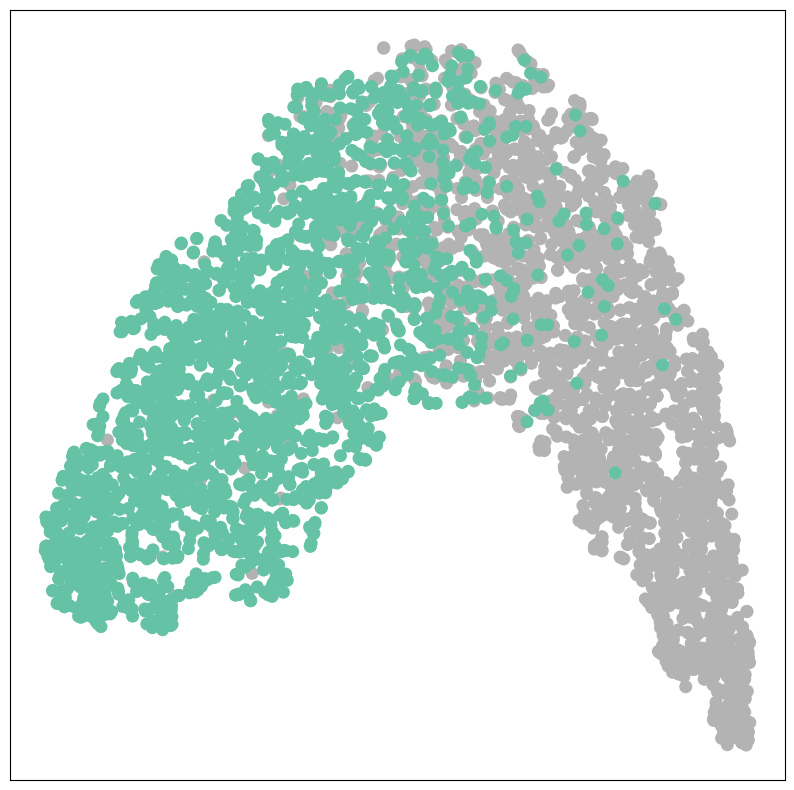

In [ ]:


# 1. Load the Best Linear Model
model_lin.load_state_dict(torch.load('best_linear_model.pt'))
model_lin.eval()

# 2. Extract a Balanced Sample from 2024 (Linear Graph)
fraud_idx = (data_test_lin.y == 1).nonzero(as_tuple=True)[0].cpu().numpy()
normal_idx = (data_test_lin.y == 0).nonzero(as_tuple=True)[0].cpu().numpy()

n_viz = min(len(fraud_idx), 2500)
viz_indices = np.concatenate([
    np.random.choice(fraud_idx, n_viz, replace=False),
    np.random.choice(normal_idx, n_viz, replace=False)
])

# 3. Generate Hidden Embeddings for Linear Weights
with torch.no_grad():
    # Pass 2024 data through the Linear-trained layers
    h1 = F.elu(model_lin.conv1(data_test_lin.x.to(device),
                               data_test_lin.edge_index.to(device),
                               data_test_lin.edge_attr.to(device)))
    h_hidden_lin = model_lin.conv2(h1,
                                   data_test_lin.edge_index.to(device),
                                   data_test_lin.edge_attr.to(device))

    h_viz_lin = h_hidden_lin[viz_indices]
    color_viz_lin = data_test_lin.y[viz_indices].flatten().cpu().numpy()

# 4. Visualize the Result
print(f"Visualizing {len(viz_indices)} nodes from the LINEAR 2024 Test Set...")
Visualize(h_viz_lin, color_viz_lin)

Visualizing 10,000 nodes with LINEAR weights and REAL imbalance...


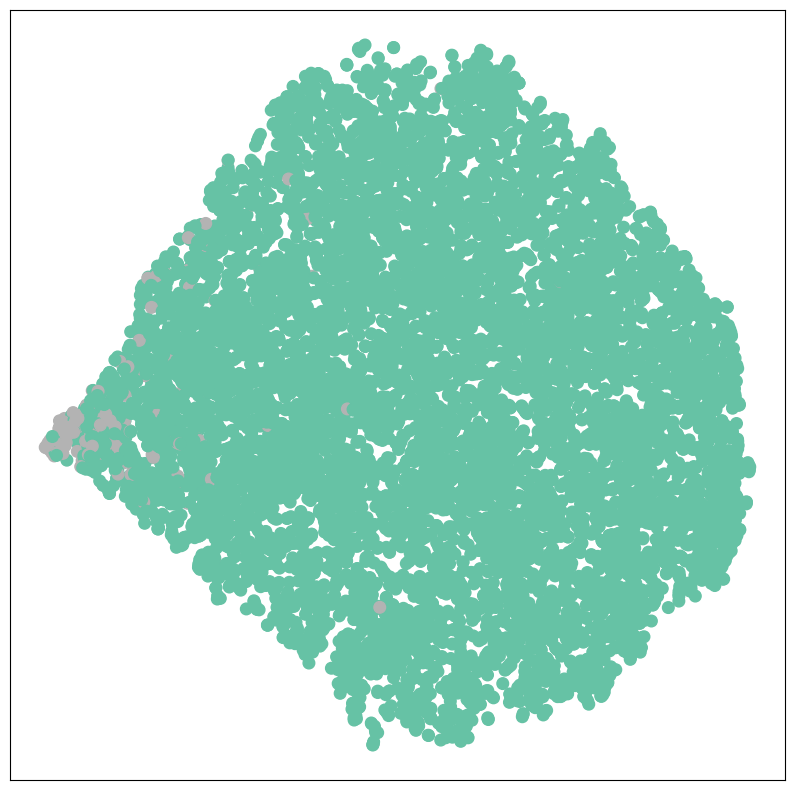

In [ ]:


# 1. Define a large enough sample to see the 'Galaxy' (10k nodes)
total_sample_size = 10000

# 2. Randomly select 10,000 indices from the 2024 Test Set (preserving imbalance)
unbalanced_indices_lin = np.random.choice(
    np.arange(len(data_test_lin.y)),
    total_sample_size,
    replace=False
)

# 3. Generate Hidden Embeddings using the Linear Model
model_lin.eval()
with torch.no_grad():
    # Pass 2024 Linear data through the trained network
    h1_lin = F.elu(model_lin.conv1(data_test_lin.x.to(device),
                                   data_test_lin.edge_index.to(device),
                                   data_test_lin.edge_attr.to(device)))
    h_hidden_lin = model_lin.conv2(h1_lin,
                                   data_test_lin.edge_index.to(device),
                                   data_test_lin.edge_attr.to(device))

    h_viz_unbalanced_lin = h_hidden_lin[unbalanced_indices_lin]
    color_viz_unbalanced_lin = data_test_lin.y[unbalanced_indices_lin].flatten().cpu().numpy()

# 4. Execute the Visualize function
print(f"Visualizing 10,000 nodes with LINEAR weights and REAL imbalance...")
Visualize(h_viz_unbalanced_lin, color_viz_unbalanced_lin)

In [ ]:
data_train_step = create_pyg_data(df_train, y_train, edge_index_train, attr_step_train)
data_val_step   = create_pyg_data(df_val, y_val, edge_index_val, attr_step_val)
data_test_step  = create_pyg_data(df_test, y_test, edge_index_test, attr_step_test)

print(f"Step Graph Ready: {data_train_step.edge_attr.unique()}") # Should show [0.1, 0.5, 1.0]

Step Graph Ready: tensor([0.2500, 0.5000, 0.7500, 1.0000])


In [ ]:
# 1. Reset Model and Optimizer
model_step = GATv2(num_node_features=data_train_step.x.shape[1], hidden_layer=16).to(device)
optimizer_step = torch.optim.AdamW(model_step.parameters(), lr=0.001, weight_decay=1e-4)

# 2. Reset Stopper
stopper_step = EarlyStopping(patience=20)
best_val_f1_step = 0

print("Starting Step-Weight Training...")

for epoch in range(1, 101):
    model_step.train()
    optimizer_step.zero_grad()

    # Forward with STEP data
    out = model_step(data_train_step.x.to(device), data_train_step.edge_index.to(device), data_train_step.edge_attr.to(device))
    loss = criterion(out, data_train_step.y.to(device))

    loss.backward()
    optimizer_step.step()

    # Validation
    val_metrics = evaluate(model_step, data_val_step.to(device))
    stopper_step(val_metrics['f1'])

    if val_metrics['f1'] > best_val_f1_step:
        best_val_f1_step = val_metrics['f1']
        torch.save(model_step.state_dict(), 'best_step_model.pt')

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Val F1: {val_metrics['f1']:.4f}")

    if stopper_step.early_stop:
        break

Starting Step-Weight Training...
Epoch 010 | Loss: 1.2578 | Val F1: 0.0830
Epoch 020 | Loss: 1.1648 | Val F1: 0.1073
Epoch 030 | Loss: 1.0714 | Val F1: 0.1259
Epoch 040 | Loss: 0.9785 | Val F1: 0.1397
Epoch 050 | Loss: 0.8825 | Val F1: 0.1659
Epoch 060 | Loss: 0.7869 | Val F1: 0.1973
Epoch 070 | Loss: 0.7021 | Val F1: 0.2344
Epoch 080 | Loss: 0.6286 | Val F1: 0.2713
Epoch 090 | Loss: 0.5667 | Val F1: 0.2957
Epoch 100 | Loss: 0.5241 | Val F1: 0.3136


Visualizing 10,000 nodes with STEP weights and REAL imbalance...


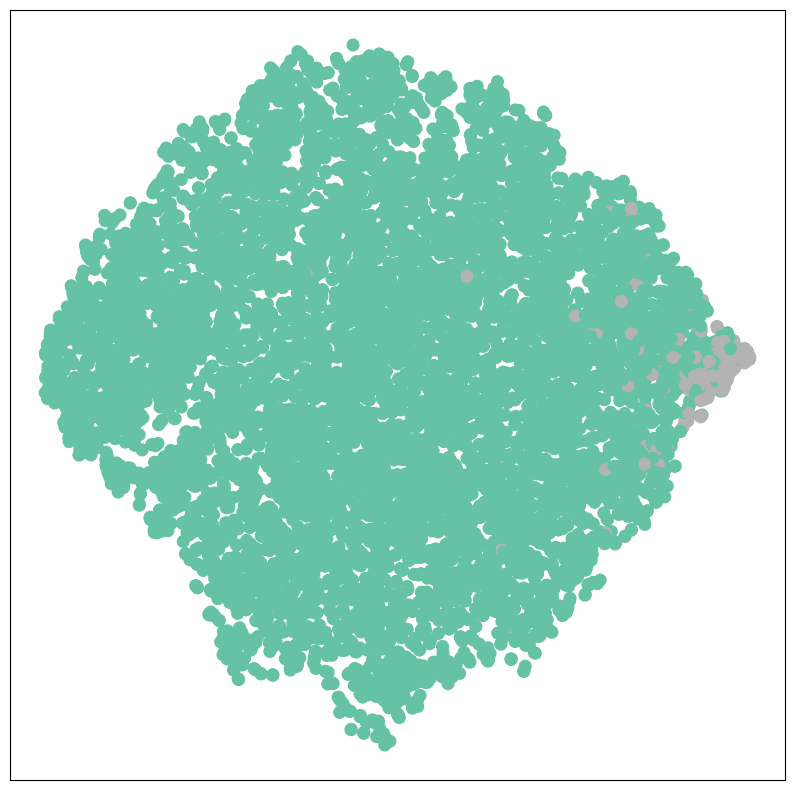

In [ ]:
# 1. Load the Best Step Model
model_step.load_state_dict(torch.load('best_step_model.pt'))
model_step.eval()

# 2. Sample 10,000 nodes (Natural Imbalance)
unbalanced_indices_step = np.random.choice(
    np.arange(len(data_test_step.y)), 10000, replace=False
)

# 3. Generate Hidden Embeddings
with torch.no_grad():
    h1_step = F.elu(model_step.conv1(data_test_step.x.to(device),
                                     data_test_step.edge_index.to(device),
                                     data_test_step.edge_attr.to(device)))
    h_hidden_step = model_step.conv2(h1_step,
                                     data_test_step.edge_index.to(device),
                                     data_test_step.edge_attr.to(device))

    h_viz_step = h_hidden_step[unbalanced_indices_step]
    color_viz_step = data_test_step.y[unbalanced_indices_step].flatten().cpu().numpy()

# 4. Final Visualization
print(f"Visualizing 10,000 nodes with STEP weights and REAL imbalance...")
Visualize(h_viz_step, color_viz_step)

Visualizing 5000 nodes (Balanced) with STEP weights...


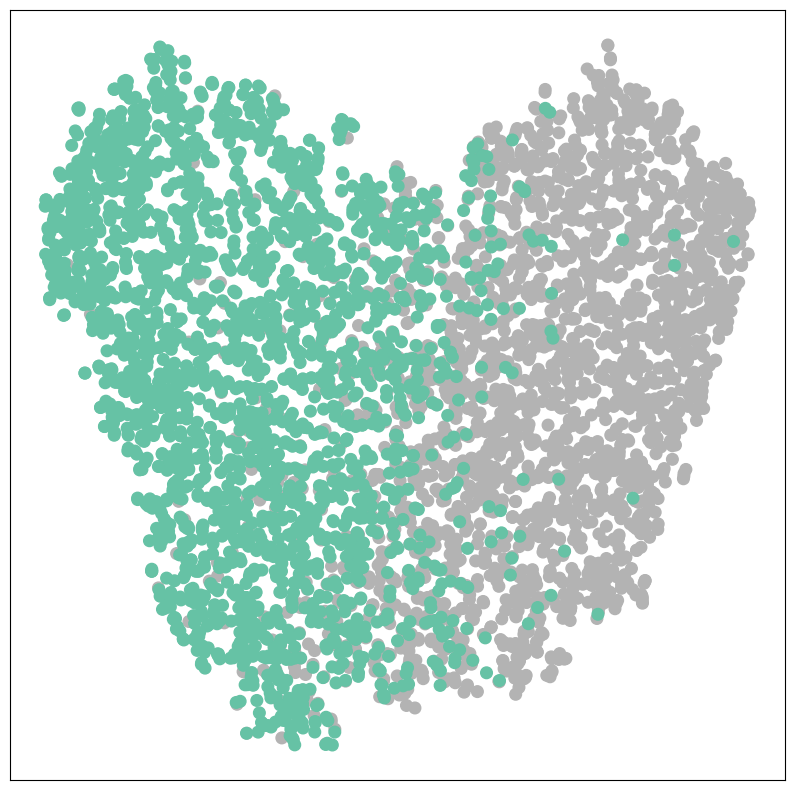

In [ ]:


# 1. Load the Best Step Model (if not already loaded)
model_step.load_state_dict(torch.load('best_step_model.pt'))
model_step.eval()

# 2. Identify indices for 2024 Fraud and Normal (Step Graph)
fraud_indices_step = (data_test_step.y == 1).nonzero(as_tuple=True)[0].cpu().numpy()
normal_indices_step = (data_test_step.y == 0).nonzero(as_tuple=True)[0].cpu().numpy()

# 3. Create a 50/50 balanced sample (e.g., 2500 each)
n_viz = min(len(fraud_indices_step), 2500)
balanced_indices_step = np.concatenate([
    np.random.choice(fraud_indices_step, n_viz, replace=False),
    np.random.choice(normal_indices_step, n_viz, replace=False)
])

# 4. Generate Hidden Embeddings
with torch.no_grad():
    h1_step = F.elu(model_step.conv1(data_test_step.x.to(device),
                                     data_test_step.edge_index.to(device),
                                     data_test_step.edge_attr.to(device)))
    h_hidden_step = model_step.conv2(h1_step,
                                     data_test_step.edge_index.to(device),
                                     data_test_step.edge_attr.to(device))

    h_viz_balanced_step = h_hidden_step[balanced_indices_step]
    color_viz_balanced_step = data_test_step.y[balanced_indices_step].flatten().cpu().numpy()

# 5. Execute the Visualize function
print(f"Visualizing {len(balanced_indices_step)} nodes (Balanced) with STEP weights...")
Visualize(h_viz_balanced_step, color_viz_balanced_step)

In [ ]:
# 1. Get raw probabilities for the LINEAR model
model_lin.eval()
with torch.no_grad():
    logits_lin = model_lin(data_test_lin.x.to(device),
                           data_test_lin.edge_index.to(device),
                           data_test_lin.edge_attr.to(device))
    probs_lin = torch.sigmoid(logits_lin).cpu().numpy()
    y_true_lin = data_test_lin.y.cpu().numpy()

# 2. Find the optimal threshold for the Linear Model
precision_lin, recall_lin, thresholds_lin = precision_recall_curve(y_true_lin, probs_lin)
f1_scores_lin = 2 * (precision_lin * recall_lin) / (precision_lin + recall_lin + 1e-8)
best_idx_lin = np.argmax(f1_scores_lin)
best_thresh_lin = thresholds_lin[best_idx_lin]

# 3. Generate Final Predictions
final_preds_lin = (probs_lin >= best_thresh_lin).astype(int)

from sklearn.metrics import classification_report
print("=== FINAL 2024 LINEAR MODEL PERFORMANCE ===")
print(f"Optimal Threshold: {best_thresh_lin:.4f}\n")
print(classification_report(y_true_lin, final_preds_lin, target_names=['Normal', 'Fraud']))

=== FINAL 2024 LINEAR MODEL PERFORMANCE ===
Optimal Threshold: 0.8523

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    328190
       Fraud       0.62      0.53      0.57      5725

    accuracy                           0.99    333915
   macro avg       0.80      0.76      0.78    333915
weighted avg       0.99      0.99      0.99    333915



In [ ]:
import torch.nn as nn

class FraudMLP(nn.Module):
    def __init__(self, num_features):
        super(FraudMLP, self).__init__()
        # Layer 1: 49 -> 64
        self.fc1 = nn.Linear(num_features, 64)
        # Layer 2: 64 -> 16 (Bottleneck)
        self.fc2 = nn.Linear(64, 16)
        # Output: 16 -> 1
        self.out = nn.Linear(16, 1)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # Notice: NO edge_index or edge_attr here. It is completely blind to the graph.
        x = F.elu(self.fc1(x))
        x = self.dropout(x)
        x = F.elu(self.fc2(x))
        return self.out(x)

# Initialize the Baseline Model
model_mlp = FraudMLP(num_features=data_train.x.shape[1]).to(device)
optimizer_mlp = torch.optim.AdamW(model_mlp.parameters(), lr=0.001, weight_decay=1e-4)

print(model_mlp)

FraudMLP(
  (fc1): Linear(in_features=49, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=16, bias=True)
  (out): Linear(in_features=16, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [ ]:
# Create a new early stopper for the MLP
stopper_mlp = EarlyStopping(patience=20)
best_val_f1_mlp = 0

print("Starting MLP Tabular Baseline Training...\n")

for epoch in range(1, 151):
    model_mlp.train()
    optimizer_mlp.zero_grad()

    # Forward pass: Only feature vectors (X), no graph structure
    out_mlp = model_mlp(data_train.x.to(device))
    loss_mlp = criterion(out_mlp, data_train.y.to(device))

    loss_mlp.backward()
    optimizer_mlp.step()

    # --- MLP EVALUATION HELPER ---
    # We write a quick inline eval since our main `evaluate` function expects graph inputs
    model_mlp.eval()
    with torch.no_grad():
        val_logits = model_mlp(data_val.x.to(device))
        val_probs = torch.sigmoid(val_logits)
        val_preds = (val_probs > 0.5).float().cpu().numpy()
        y_true_val = data_val.y.cpu().numpy()

        from sklearn.metrics import f1_score
        val_f1_mlp = f1_score(y_true_val, val_preds, zero_division=0)

    stopper_mlp(val_f1_mlp)

    if val_f1_mlp > best_val_f1_mlp:
        best_val_f1_mlp = val_f1_mlp
        torch.save(model_mlp.state_dict(), 'best_mlp_model.pt')

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss: {loss_mlp:.4f} | Val F1: {val_f1_mlp:.4f}")

    if stopper_mlp.early_stop:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

Starting MLP Tabular Baseline Training...

Epoch 001 | Loss: 1.3433 | Val F1: 0.0842
Epoch 010 | Loss: 1.2682 | Val F1: 0.1040
Epoch 020 | Loss: 1.1765 | Val F1: 0.1144
Epoch 030 | Loss: 1.0653 | Val F1: 0.1257
Epoch 040 | Loss: 0.9510 | Val F1: 0.1369
Epoch 050 | Loss: 0.8418 | Val F1: 0.1561
Epoch 060 | Loss: 0.7448 | Val F1: 0.1848
Epoch 070 | Loss: 0.6460 | Val F1: 0.2317
Epoch 080 | Loss: 0.5585 | Val F1: 0.2898
Epoch 090 | Loss: 0.4904 | Val F1: 0.3317
Epoch 100 | Loss: 0.4415 | Val F1: 0.3402
Epoch 110 | Loss: 0.4073 | Val F1: 0.3462
Epoch 120 | Loss: 0.3854 | Val F1: 0.3595
Epoch 130 | Loss: 0.3687 | Val F1: 0.3721
Epoch 140 | Loss: 0.3560 | Val F1: 0.3775
Epoch 150 | Loss: 0.3445 | Val F1: 0.3824


Visualizing 5000 nodes from the GRAPH-BLIND MLP Baseline...


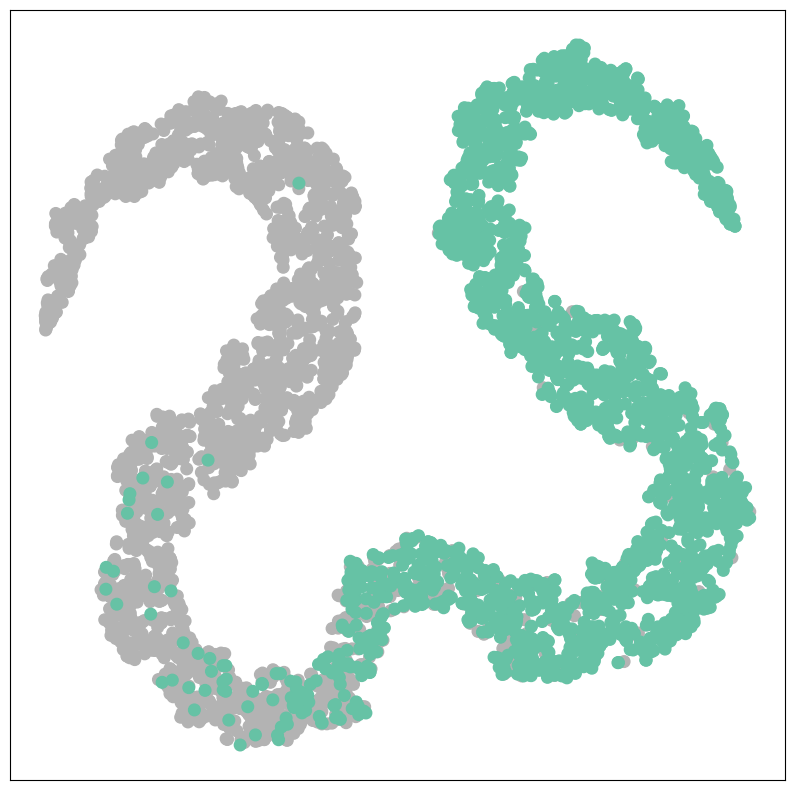

In [ ]:


# 1. Load the Best MLP Model weights (Epoch 9 or earlier, depending on patience)
model_mlp.load_state_dict(torch.load('best_mlp_model.pt'))
model_mlp.eval()

# 2. Get indices for a 50/50 Balanced Sample from 2024
fraud_idx = (data_test.y == 1).nonzero(as_tuple=True)[0].cpu().numpy()
normal_idx = (data_test.y == 0).nonzero(as_tuple=True)[0].cpu().numpy()

n_viz = min(len(fraud_idx), 2500)
viz_indices_mlp = np.concatenate([
    np.random.choice(fraud_idx, n_viz, replace=False),
    np.random.choice(normal_idx, n_viz, replace=False)
])

# 3. Extract the 16-Dimensional Hidden Embeddings from the MLP
with torch.no_grad():
    # Pass 2024 features through FC1 -> ELU -> FC2
    h1_mlp = F.elu(model_mlp.fc1(data_test.x.to(device)))
    # We stop here to grab the 16-D bottleneck (same size as GATv2 hidden layer)
    h_hidden_mlp = F.elu(model_mlp.fc2(h1_mlp))

    h_viz_mlp = h_hidden_mlp[viz_indices_mlp]
    color_viz_mlp = data_test.y[viz_indices_mlp].flatten().cpu().numpy()

# 4. Run the Visualization
print(f"Visualizing {len(viz_indices_mlp)} nodes from the GRAPH-BLIND MLP Baseline...")
Visualize(h_viz_mlp, color_viz_mlp)

Visualizing 10,000 nodes from the GRAPH-BLIND MLP (Real Imbalance)...


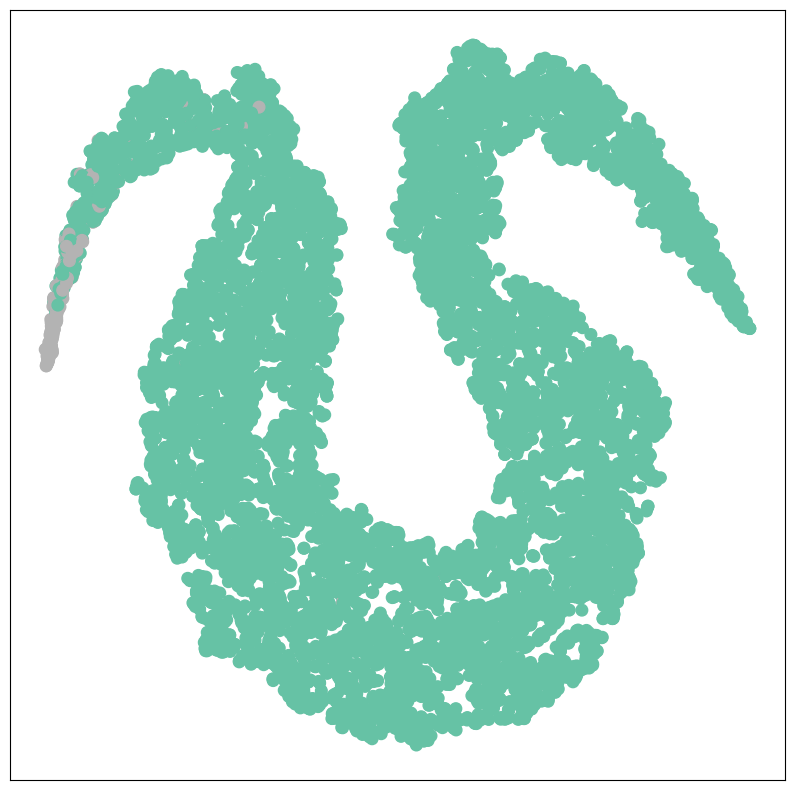

In [ ]:


# 1. Sample 10,000 nodes preserving the natural 57:1 imbalance
unbalanced_indices_mlp = np.random.choice(
    np.arange(len(data_test.y)), 10000, replace=False
)

# 2. Extract Hidden Embeddings
model_mlp.eval()
with torch.no_grad():
    h1_mlp_unb = F.elu(model_mlp.fc1(data_test.x.to(device)))
    h_hidden_mlp_unb = F.elu(model_mlp.fc2(h1_mlp_unb))

    h_viz_mlp_unb = h_hidden_mlp_unb[unbalanced_indices_mlp]
    color_viz_mlp_unb = data_test.y[unbalanced_indices_mlp].flatten().cpu().numpy()

# 3. Final MLP Visualization
print(f"Visualizing 10,000 nodes from the GRAPH-BLIND MLP (Real Imbalance)...")
Visualize(h_viz_mlp_unb, color_viz_mlp_unb)